# 빈도 수 기반 텍스트 분석 : 다음 영화 리뷰

1.  데이터 준비 : 로딩, 필요한 데이터 추출
2.  데이터 전처리: 분석 대칭 단어 집합
3.  데이터 분석: 빈도수
4.  시각화 : 수평 막대 그래프, 워드 클라우드



### 1. 데이터 준비

In [6]:
import pandas as pd

# 사용자 이름을 'user'로 수정하고 경로 앞에 r을 붙여줍니다.(r 은 있는 그대로 해석하라고 알려줌)
datafile = r"C:\Users\user\Desktop\26년 폴리텍 대학 인공지능 SW 강의 자료 모음\이혜정 교수님(파이썬 기반 쥬피터 이용 코드 모음 (백준 코드 포함)\textmine_26\data\daum_movie_review.csv"

data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [9]:
reviews = list(data_df.review)
len(reviews), reviews[:5]

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

### 2. 데이터 전처리 → 단어집합

In [8]:
import os

# 1. Java 설치 경로를 환경 변수에 직접 등록 (r을 꼭 붙여주세요)
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-26.0.1'

from konlpy.tag import Okt
t = Okt()

# 모든 리뷰를 하나로 합쳐서 명사 추출
all_reviews = " ".join(data_df.review.astype(str))
nouns = t.nouns(all_reviews)

# 토큰 수
print(f'토큰수: {len(nouns):,}개')

# 토큰 일부 확인
nouns[:10]

토큰수: 126,063개


['돈', '티', '나', '내내', '하품', '몰입', '생각', '내', '전투', '참여']

In [10]:
# 1. 제거할 단어(불용어)와 추출할 품사 정의
# 분석에서 제외할 의미 없는 단어들을 리스트로 만듭니다.
my_stopwords = ['만', '하는', '때'] 

# 형태소 분석 결과 중 결과에 포함시킬 품사들을 지정합니다. (명사, 동사, 형용사)
my_tags = ['Noun', 'Verb', 'Adjective'] 

# 2. 리스트 컴프리헨션을 이용한 단어 필터링 및 추출
# t.pos(all_reviews): 전체 텍스트를 형태소 분석하여 (단어, 품사) 쌍의 리스트로 반환합니다.
# [조건 1] tag in my_tags: 지정한 품사(명사, 동사, 형용사)에 해당해야 함
# [조건 2] word not in my_stopwords: 정의한 불용어 목록에 포함되지 않아야 함
# [조건 3] len(word): 단어의 길이가 1자 이상이어야 함 (빈 문자열 제외)
tokens = [word for word, tag in t.pos(all_reviews) if tag in my_tags and word not in my_stopwords and len(word)]

# 3. 추출된 결과 확인
# 필터링을 거쳐 최종적으로 추출된 단어(토큰)의 총 개수를 출력합니다.
# {len(tokens):,}는 숫자에 천 단위 쉼표를 찍어 가독성을 높입니다.
print(f'토큰수: {len(tokens):,}개')

# 전체 토큰 리스트 중 앞부분 10개만 출력하여 제대로 추출되었는지 확인합니다.
tokens[:30]

토큰수: 193,377개


['돈',
 '들인건',
 '티',
 '나',
 '보는',
 '내내',
 '하품',
 '몰입',
 '할수밖에',
 '없다',
 '어렵게',
 '생각',
 '할',
 '필요없다',
 '내',
 '전투',
 '참여',
 '듯',
 '손',
 '땀',
 '이남',
 '이전',
 '작품',
 '비해',
 '더',
 '화려하고',
 '스케일',
 '커졌지만',
 '전국',
 '맛집']

## 3. 빈도수 계산


In [11]:
# Counter 객체 생성
from  collections import Counter #빈도수 객체 사용 시 사용 가능
const_counter = Counter(tokens) 
# 단어 수
print(len(const_counter))
# Counter 객체 내 (단어, 빈도수) 확인
list(const_counter.items())[:10]

26509


[('돈', 489),
 ('들인건', 1),
 ('티', 49),
 ('나', 353),
 ('보는', 401),
 ('내내', 170),
 ('하품', 33),
 ('몰입', 210),
 ('할수밖에', 2),
 ('없다', 195)]

In [12]:
#빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common

<bound method Counter.most_common of Counter({'영화': 6691, '연기': 1293, '감동': 1223, '생각': 1027, '정말': 948, '것': 927, '이': 851, '배우': 847, '사람': 819, '스토리': 815, '더': 791, '진짜': 781, '잘': 776, '눈물': 737, '보고': 709, '점': 692, '최고': 682, '좀': 671, '재미': 641, '마지막': 612, '그': 610, '시간': 596, '입니다': 580, '마동석': 556, '수': 536, '그냥': 533, '정도': 531, '광주': 530, '윤계상': 517, '기대': 516, '내용': 494, '돈': 489, '할': 480, '볼': 476, '꼭': 468, '장면': 438, '있는': 433, '원작': 422, '내': 421, '말': 420, '본': 418, '평점': 407, '왜': 407, '봤는데': 403, '보는': 401, '느낌': 400, '신파': 387, '좋은': 377, '듯': 366, '나': 353, '중간': 348, '합니다': 344, '편': 340, '재밌게': 335, '가족': 335, '마블': 334, '봤습니다': 334, '감독': 333, '이런': 332, '다시': 322, '한국': 321, '같은': 320, '안': 320, '함': 320, '없는': 316, '처음': 310, '거': 309, '뭐': 307, '끝': 305, '부분': 302, '역사': 299, '해서': 295, '음악': 290, '넘': 286, '우리': 277, '가슴': 277, '봤어요': 275, '한번': 273, '임': 271, '한': 268, '액션': 268, '또': 262, '송강호': 261, '공포영화': 259, '인생': 258, '하나': 258, '별로': 258, '역시': 2

## 4. 단어 빈도 그래프 시각화
1. 데이터 준비
2. 그래프 정보 추가
3. 막대 그래프 생성
4. 그래프 출력 (화면, 파일)

In [13]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
x=[word for word, count in const_counter.most_common(20)]
y=[count for count, count in const_counter.most_common(20)]
print(x[:10])
print(y[:10])

['영화', '연기', '감동', '생각', '정말', '것', '이', '배우', '사람', '스토리']
[6691, 1293, 1223, 1027, 948, 927, 851, 847, 819, 815]


In [14]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)


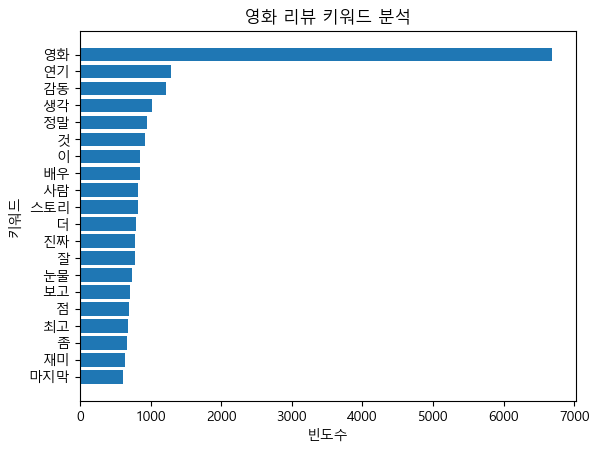

In [15]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.barh(x[::-1],y[::-1])
# 그래프 정보 추가 
plt.title('영화 리뷰 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')
input_filename = '다음영화 리뷰.txt'
outputfile = input_filename.replace('.txt', '_bargraph.png')
plt.savefig(outputfile)
# 화면에 출력 (출력 시 저장이 사라짐)
# plt.show

In [16]:
# 그래프 저장 : 그래프 생성 후 바로 savefig 사용
outputfile = input_filename.replace('.txt', '_bargraph.png')
plt.savefig(outputfile)

<Figure size 640x480 with 0 Axes>

## 03-5. 워드 클라우드 시각화
 ● Conda 환경에서 wordcloud 설치 이후 사용 가능


In [2]:

import sys
!{sys.executable} -m pip install wordcloud


In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(font_path=font_path,
                     height= 600,
                     width= 800,
                     max_words= 50,
                     background_color='ivory'
                     )

<function matplotlib.pyplot.show(close=None, block=None)>

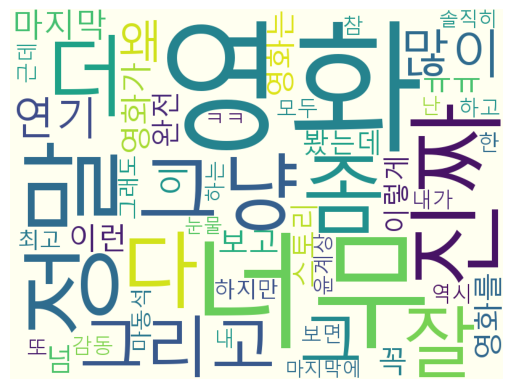

In [18]:
# 전체 텍스트로 워드클라우드 시각화
const_wc = const_wc.generate(all_reviews)
plt.axis('off')
plt.imshow(const_wc)
plt.show